<a href="https://colab.research.google.com/github/AlexandraRawrrr/python_for_ds_tasks/blob/main/Copy_of_HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [4]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('/content/drive/MyDrive/yulu_rental.csv')


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [7]:
df.shape

(10886, 19)

In [8]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


У таблиці 10886 рядків даних, кожен рядок має 1 годину даних, тобто оновлюються погодинно.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


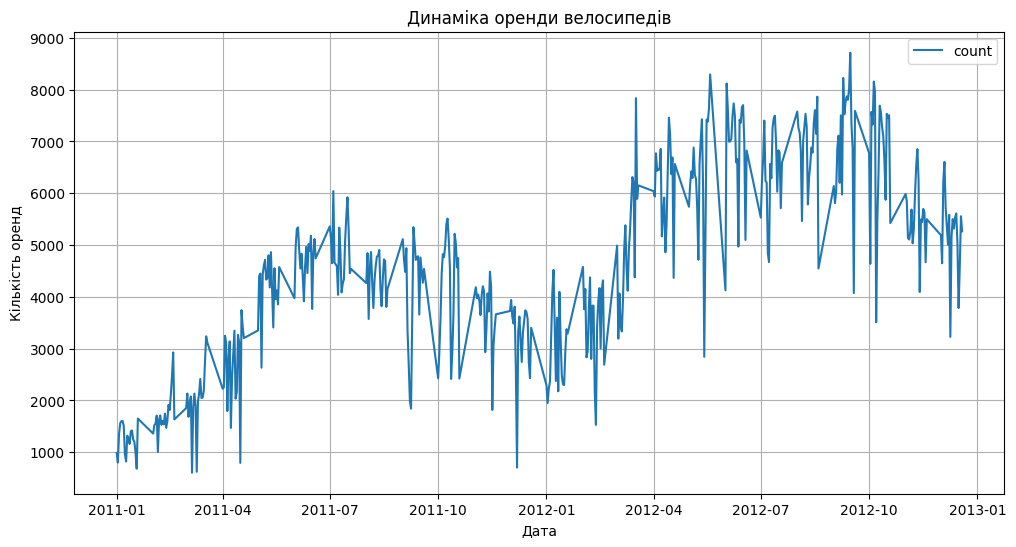

In [9]:
df['date'] = pd.to_datetime(df['date'])

daily_count = (
    df.groupby(df['date'].dt.date)['count']
    .sum()
    .to_frame(name='count')
)

daily_count.plot(figsize=(12, 6))

plt.title('Динаміка оренди велосипедів')
plt.xlabel('Дата')
plt.ylabel('Кількість оренд')
plt.grid(True)

plt.show()

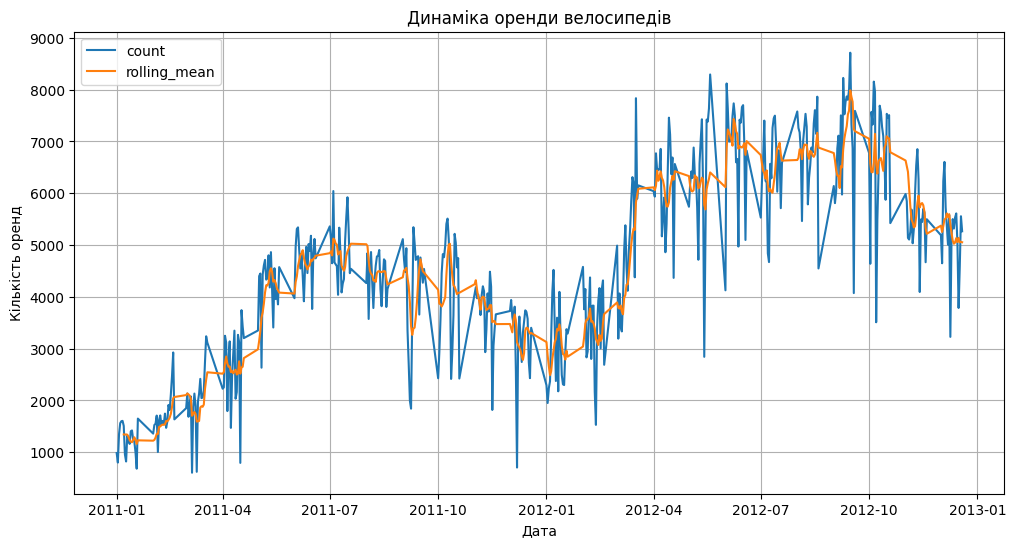

In [10]:
daily_count['rolling_mean'] = daily_count['count'].rolling(window=7).mean()

daily_count.plot(figsize=(12, 6))

plt.title('Динаміка оренди велосипедів')
plt.xlabel('Дата')
plt.ylabel('Кількість оренд')
plt.grid(True)

plt.show()



1.   Заломи спричинені тим, що немає плавного переходу між часовими даними і треба округлити перехід між датами. Ми могли би це усунути завдяки середьньому значенню, так графік буде читатися трохи легше. Хоча, на мою думку, цей вид графіку не дуже зрозумілий з точки зору продажів, сугубо якщо дивитись динаміку.
2. На графіку бачу яскраво виражену тенденцію зростання кількості оренди велосипедів, але не поступове, а більш сезонне.  
3.   Точно можна побачити сезонність оренди, вона просідає у холодну пору року і зростає з потеплінням.
4. На графіку яскраво видно коливання, що може бути спричинено погодними умовами, святами, або іншими особливими подіями.



## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [11]:
df['date'] = pd.to_datetime(df['date'])

df['quarter'] = df['date'].dt.quarter

quarter_avg = df.groupby('quarter')['count'].mean()

quarter_avg

,count
quarter,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


In [12]:
quarter_names = {
    1: 'I квартал',
    2: 'II квартал',
    3: 'III квартал',
    4: 'IV квартал'
}

quarter_avg.index = quarter_avg.index.map(quarter_names)

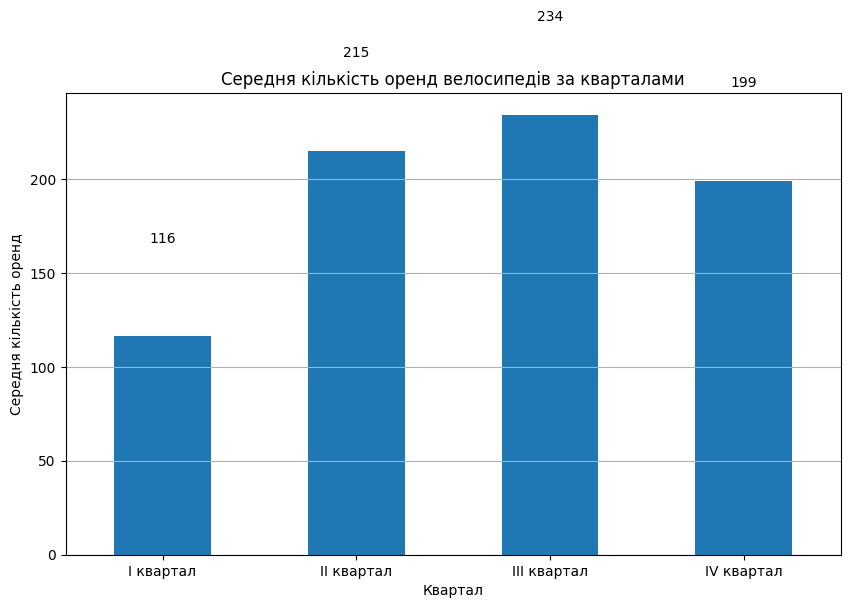

In [13]:
ax = quarter_avg.plot(
    kind='bar',
    figsize=(10, 6)
)

for i, value in enumerate(quarter_avg):
    ax.text(i, value + 50, f'{value:.0f}', ha='center')

plt.title('Середня кількість оренд велосипедів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')

plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [14]:
max_quarter = quarter_avg.max()
min_quarter = quarter_avg.min()

ratio = max_quarter / min_quarter

print(f'Найпопулярніший квартал: {quarter_avg.idxmax()}')
print(f'Найменш популярний квартал: {quarter_avg.idxmin()}')
print(f'Відмінність: {ratio:.2f} рази')

Найпопулярніший квартал: III квартал
Найменш популярний квартал: I квартал
Відмінність: 2.01 рази


В який квартал найбільша середня кількість оренди велосипедів?
Як ви можете пояснити таку сезонну закономірність?
У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

Сезонну заканомірність можна пояснити абсолютно логічно: тепла погода сприяє оренді, а також це може йти в пару до сезону відпусток.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [15]:
df['date'] = pd.to_datetime(df['date'])

monthly_avg = df.groupby(df['date'].dt.month)['count'].mean()

monthly_avg

,count
date,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


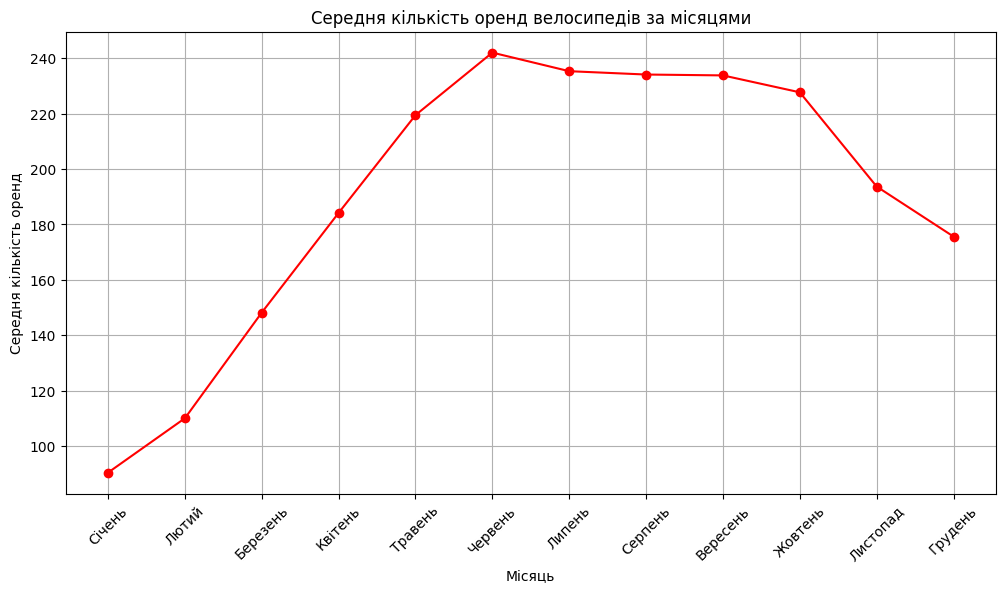

In [16]:
import matplotlib.pyplot as plt

month_names = [
    'Січень', 'Лютий', 'Березень', 'Квітень',
    'Травень', 'Червень', 'Липень', 'Серпень',
    'Вересень', 'Жовтень', 'Листопад', 'Грудень'
]

monthly_avg.index = range(12)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',
    color='red'
)

plt.title('Середня кількість оренд велосипедів за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')

plt.xticks(range(12), month_names, rotation=45)
plt.grid(True)

plt.show()

Питання для інтерпретації:

1. В які місяці спостерігається пік та спад оренди?
  Пік оренди спостерігається влітку та на початку осені, а найнижчі значення — взимку.
2. Чи збігається ця закономірність з результатами з попереднього завдання?
  Так, результати узгоджуються. У попередньому завданні також було видно, що найбільша кількість оренд припадає на теплу пору року, а найменша — на холодну.
3. Як може вплинути клімат на оренду велосипедів протягом року?
  Клімат має значний вплив на попит. Тепла та суха погода сприяє використанню велосипедів, тому кількість оренд зростає. Низькі температури, опади, сильний вітер та інші несприятливі погодні умови можуть суттєво зменшувати попит.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

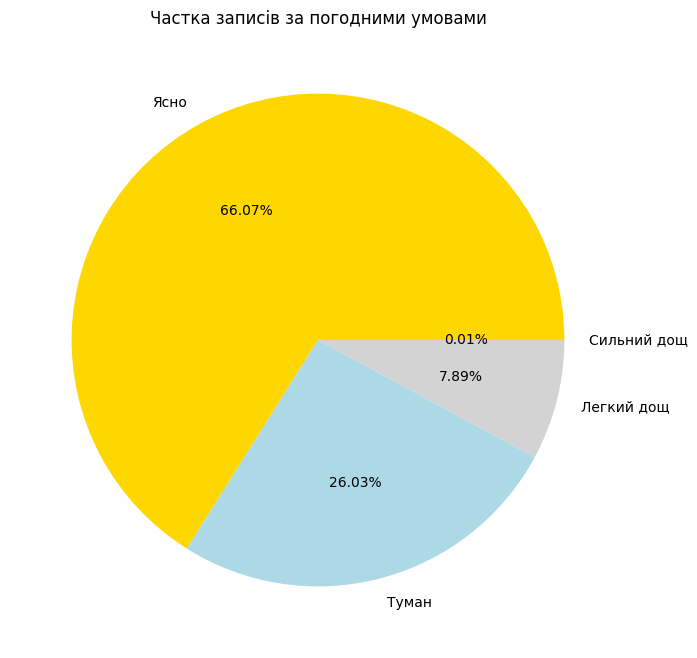

In [17]:
weather_counts = df['weather'].value_counts().sort_index()

weather_names = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

weather_counts.index = weather_counts.index.map(weather_names)

weather_counts

,count
weather,
Ясно,7192
Туман,2834
Легкий дощ,859
Сильний дощ,1


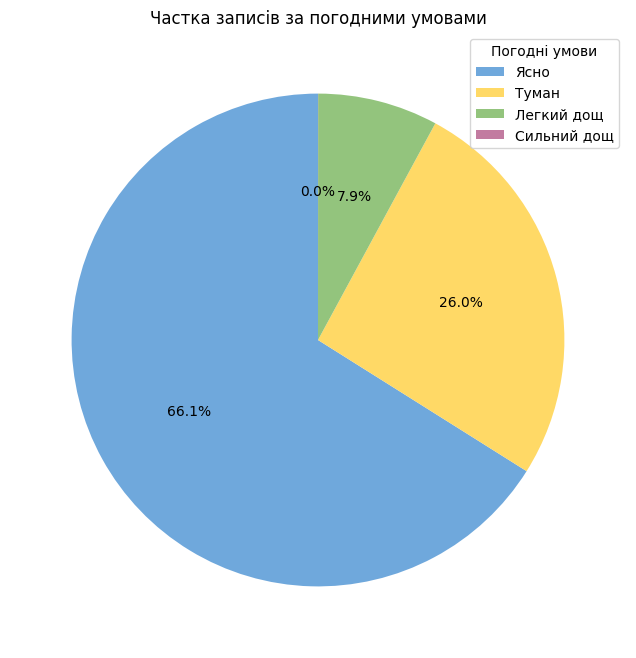

In [18]:
colors = ['#6FA8DC', '#FFD966', '#93C47D', '#C27BA0']

plt.figure(figsize=(8, 8))

plt.pie(
    weather_counts,
    labels=None,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title('Частка записів за погодними умовами')

plt.legend(
    weather_counts.index,
    title='Погодні умови',
    loc='best'
)

plt.show()

In [19]:
strong_rain_share = (df['weather'] == 4).mean() * 100

print(f'Частка записів із сильним дощем: {strong_rain_share:.2f}%')

Частка записів із сильним дощем: 0.01%


In [20]:
print(f"Кількість записів із сильним дощем: {(df['weather'] == 4).sum()}")
print(f"Частка: {strong_rain_share:.2f}%")

Кількість записів із сильним дощем: 1
Частка: 0.01%


Питання для інтерпретації:

1. Яка погода переважає в датасеті?
В датасеті переважає ясна погода.

2. Чи є дні із сильним дощем? Яка їх частка?
Так, але його часта мізерно мала, всього 1 випадок.

3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?
Сприятливі погодні умови, зокрема ясна та суха погода, сприяють збільшенню попиту на оренду велосипедів. Туман, дощ та особливо сильний дощ можуть зменшувати кількість оренд, оскільки користуватися велосипедом у таких умовах менш комфортно та безпечно.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

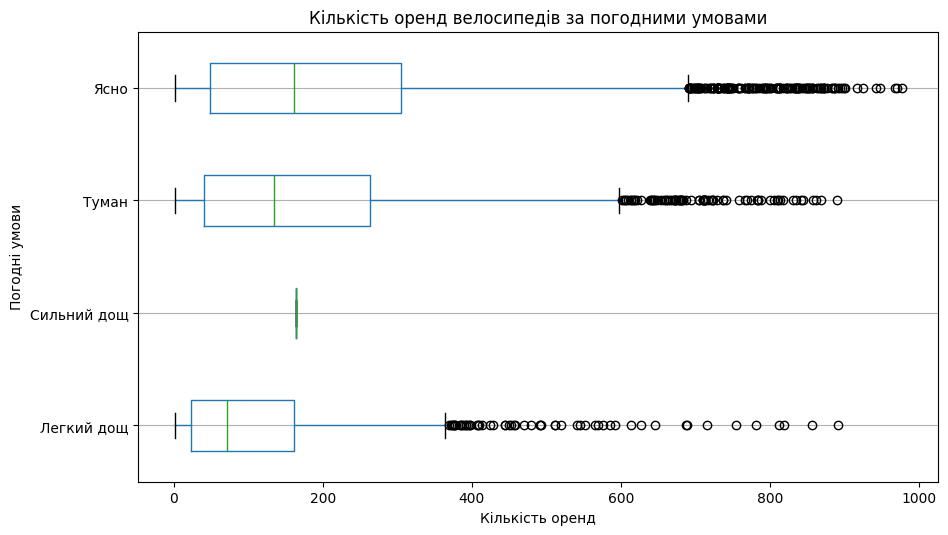

In [21]:
weather_names = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

weather_data = df.copy()
weather_data['weather_name'] = weather_data['weather'].map(weather_names)

ax = weather_data.boxplot(
    column='count',
    by='weather_name',
    vert=False,
    figsize=(10, 6)
)

plt.title('Кількість оренд велосипедів за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.grid(axis='x')

plt.show()

In [22]:
iqr = df.groupby('weather')['count'].agg(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)

iqr.index = iqr.index.map(weather_names)

print(iqr)
print('\nНайбільший розкид:', iqr.idxmax())

weather
Ясно           257.0
Туман          223.0
Легкий дощ     138.0
Сильний дощ      0.0
Name: count, dtype: float64

Найбільший розкид: Ясно


In [23]:
outliers = {}

for weather, group in df.groupby('weather'):
    q1 = group['count'].quantile(0.25)
    q3 = group['count'].quantile(0.75)
    iqr_value = q3 - q1

    lower = q1 - 1.5 * iqr_value
    upper = q3 + 1.5 * iqr_value

    outliers[weather_names[weather]] = (
        (group['count'] < lower) | (group['count'] > upper)
    ).sum()

print('Кількість викидів:')
print(outliers)

Кількість викидів:
{'Ясно': np.int64(160), 'Туман': np.int64(82), 'Легкий дощ': np.int64(56), 'Сильний дощ': np.int64(0)}


In [25]:
median = df.groupby('weather')['count'].median()
median.index = median.index.map(weather_names)

print(median)
print('\nНайвища медіана:', median.idxmax())

weather
Ясно           161.0
Туман          134.0
Легкий дощ      71.0
Сильний дощ    164.0
Name: count, dtype: float64

Найвища медіана: Сильний дощ


Питання для інтерпретації:

1. При якій погоді найбільший розкид у кількості оренди?
Найбільший розкид у кількості оренд спостерігається при ясній погоді.
2. Чи є викиди (outliers) в даних? При якій погоді?
 Так, у даних є викиди. Вони спостерігаються при ясній погоді — 160 викидів, тумані — 82 та легкому дощі — 56. При сильному дощі викидів не виявлено.
3. При якій погоді медіанне значення оренди найвище?
Найвище медіанне значення кількості оренд спостерігається при сильному дощі — 164 оренди, але це пов'язано з тим, що категорія сильний дощ представлена невеликою кількістю значень.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

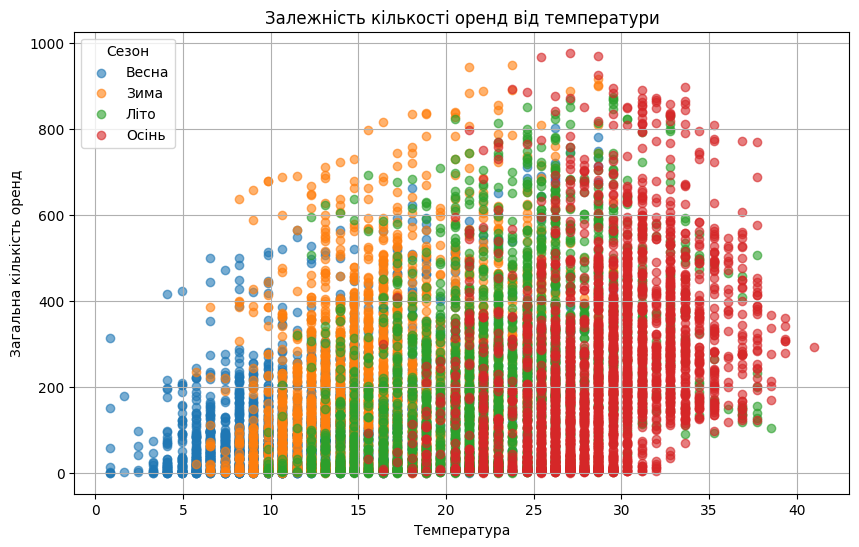

In [26]:
season_names = {
    1: 'Весна',
    2: 'Літо',
    3: 'Осінь',
    4: 'Зима'
}

df['season_name'] = df['season'].map(season_names)

plt.figure(figsize=(10, 6))

for season, group in df.groupby('season_name'):
    plt.scatter(
        group['temp'],
        group['count'],
        alpha=0.6,
        label=season
    )

plt.title('Залежність кількості оренд від температури')
plt.xlabel('Температура')
plt.ylabel('Загальна кількість оренд')
plt.legend(title='Сезон')
plt.grid(True)

plt.show()

Так, між температурою та кількістю оренд є позитивний зв'язок: зі зростанням температури кількість оренд загалом збільшується. Водночас зв'язок не є абсолютно лінійним, оскільки на попит також впливають сезон, погода та інші фактори.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [32]:
weekday_names = {
    'Sunday': 'Неділя',
    'Monday': 'Понеділок',
    'Tuesday': 'Вівторок',
    'Wednesday': 'Середа',
    'Thursday': 'Четвер',
    'Friday': 'П’ятниця',
    'Saturday': 'Субота'
}

weekday_avg = df.groupby('weekday')[['casual', 'registered']].mean()

weekday_avg.index = weekday_avg.index.map(weekday_names)

weekday_avg

,casual,registered
weekday,,
П’ятниця,31.001962,166.842381
Понеділок,29.843972,160.546744
Субота,63.625000,133.040404
Неділя,57.051298,123.788474
Четвер,24.007083,173.289118
Вівторок,22.979207,166.744639
Середа,22.521599,165.889749


In [34]:
weekday_order = [
    'Понеділок',
    'Вівторок',
    'Середа',
    'Четвер',
    'П’ятниця',
    'Субота',
    'Неділя'
]

weekday_avg = weekday_avg.reindex(weekday_order)

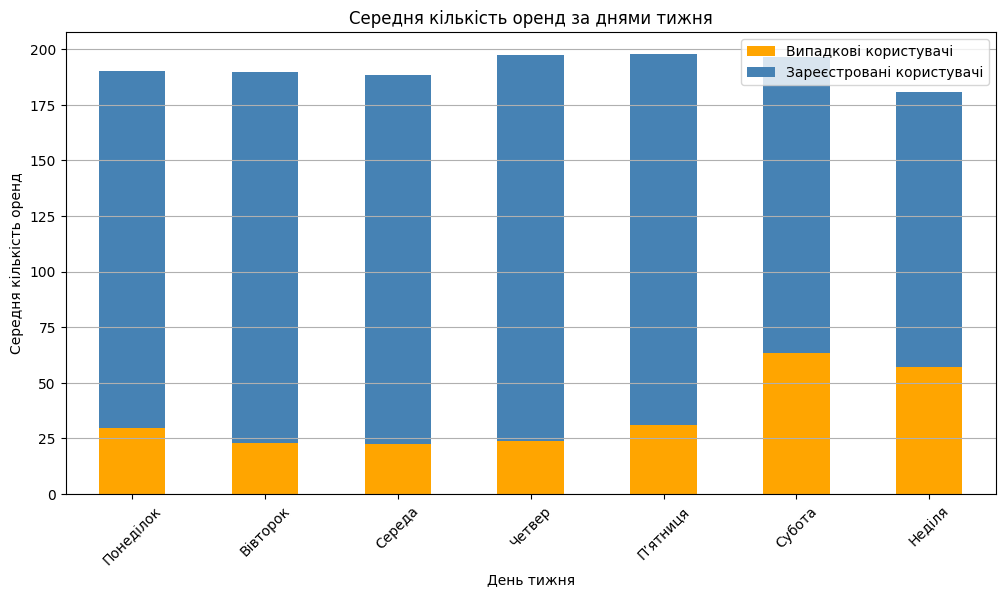

In [35]:
ax = weekday_avg.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['orange', 'steelblue']
)

plt.title('Середня кількість оренд за днями тижня')
plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд')

plt.xticks(rotation=45)
plt.legend(['Випадкові користувачі', 'Зареєстровані користувачі'])
plt.grid(axis='y')

plt.show()

Питання для інтерпретації:

1. В які дні тижня більше оренд від зареєстрованих користувачів?
Зареєстровані користувачі здійснюють більше оренд у робочі дні, особливо в середині робочого тижня.

2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?
Зареєстровані користувачі, ймовірно, частіше використовують велосипеди для регулярних поїздок, наприклад на роботу або навчання, тому їхня активність вища у робочі дні. Випадкові користувачі можуть частіше орендувати велосипеди для відпочинку та прогулянок, тому їхня активність відносно вища у вихідні.